# Mini Projet PySpark
Analyse des transports en commun d'Île-de-France

## I - Exploration et compréhension des données

### 1. Chargement des données

On commence par récupérer les fichiers grâce à des commandes HDFS exécutées dans le terminal de Jupyter :

* hdfs dfs -mkdir -p /user/ldixne01/data/IDFM-gtfs

* hdfs dfs -put /data/IDFM-gtfs/* /user/ldixne01/data/IDFM-gtfs/

In [17]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType


In [ ]:
# Initialisation de la session Spark
spark = SparkSession.builder \
    .appName("Projet_GTFS_IDF") \
    .master("yarn") \
    .getOrCreate()

Création des schémas des tables

In [7]:
# 1. Schema pour stops.txt (Les arrêts)
schema_stops = StructType([
    StructField("stop_id", StringType(), True),
    StructField("stop_code", StringType(), True),
    StructField("stop_name", StringType(), True),
    StructField("stop_desc", StringType(), True),
    StructField("stop_lat", DoubleType(), True),
    StructField("stop_lon", DoubleType(), True),
    StructField("zone_id", StringType(), True),
    StructField("stop_url", StringType(), True),
    StructField("location_type", IntegerType(), True),
    StructField("parent_station", StringType(), True)
])

# 2. Schema pour stop_times.txt (Les horaires)
schema_stop_times = StructType([
    StructField("trip_id", StringType(), True),
    StructField("arrival_time", StringType(), True),
    StructField("departure_time", StringType(), True),
    StructField("stop_id", StringType(), True),
    StructField("stop_sequence", IntegerType(), True),
    StructField("stop_headsign", StringType(), True),
    StructField("pickup_type", IntegerType(), True),
    StructField("drop_off_type", IntegerType(), True),
    StructField("shape_dist_traveled", DoubleType(), True)
])

# 3. Schema pour routes.txt (Les lignes)
schema_routes = StructType([
    StructField("route_id", StringType(), True),
    StructField("agency_id", StringType(), True),
    StructField("route_short_name", StringType(), True),
    StructField("route_long_name", StringType(), True),
    StructField("route_desc", StringType(), True),
    StructField("route_type", IntegerType(), True),
    StructField("route_url", StringType(), True),
    StructField("route_color", StringType(), True),
    StructField("route_text_color", StringType(), True)
])

# 4. Schema pour trips.txt (Les voyages)
schema_trips = StructType([
    StructField("route_id", StringType(), True),
    StructField("service_id", StringType(), True),
    StructField("trip_id", StringType(), True),
    StructField("trip_headsign", StringType(), True),
    StructField("trip_short_name", StringType(), True),
    StructField("direction_id", IntegerType(), True),
    StructField("block_id", StringType(), True),
    StructField("shape_id", StringType(), True)
])

# 5. Schema pour agency.txt (Les transporteurs)
schema_agency = StructType([
    StructField("agency_id", StringType(), True),
    StructField("agency_name", StringType(), True),
    StructField("agency_url", StringType(), True),
    StructField("agency_timezone", StringType(), True),
    StructField("agency_lang", StringType(), True),
    StructField("agency_phone", StringType(), True),
    StructField("agency_fare_url", StringType(), True),
    StructField("agency_email", StringType(), True)
])

print("Schémas chargés avec succès.")

Schémas chargés avec succès.


### 2. Structure des données

Affichage des schémas

In [9]:
base_path = "/user/ldixne01/data/IDFM-gtfs/"

# Options pour nettoyer les espaces dans les CSV
csv_opts = {
    "header": "true",
    "ignoreLeadingWhiteSpace": "true",
    "ignoreTrailingWhiteSpace": "true"
}

# 1. Chargement (Stops, Routes, Trips, Agency avec schéma strict)
df_stops = spark.read.schema(schema_stops).options(**csv_opts).csv(base_path + "stops.txt")
df_routes = spark.read.schema(schema_routes).options(**csv_opts).csv(base_path + "routes.txt")
df_trips = spark.read.schema(schema_trips).options(**csv_opts).csv(base_path + "trips.txt")
df_agency = spark.read.schema(schema_agency).options(**csv_opts).csv(base_path + "agency.txt")

# Chargement robuste pour stop_times
df_stop_times = spark.read.options(**csv_opts).option("inferSchema", "false").csv(base_path + "stop_times.txt")

# Mise en Cache
# (Le .unpersist() évite le warning si on relance la cellule, c'est plus propre)
df_stops.unpersist()
df_routes.unpersist()
df_trips.unpersist()

df_stops.cache()
df_routes.cache()
df_trips.cache()

# 2. Affichage Volumétrie
print("--- Volumétrie des données ---")

c_agency = df_agency.count()
c_routes = df_routes.count()
c_stops = df_stops.count()
c_trips = df_trips.count()
c_stop_times = df_stop_times.count()

print(f"Agency (Transporteurs) : {c_agency}")
print(f"Routes (Lignes)        : {c_routes}")
print(f"Stops (Arrêts)         : {c_stops}")
print(f"Trips (Voyages)        : {c_trips}")
print(f"Stop_Times (Horaires)  : {c_stop_times}")

# 3. Affichage des Schémas
# C'est ici que j'avais oublié de définir la variable 'dataframes' !
dataframes = {
    "STOPS": df_stops,
    "ROUTES": df_routes,
    "TRIPS": df_trips,
    "AGENCY": df_agency,
    "STOP_TIMES": df_stop_times
}

print("\n" + "="*30)
print(" AFFICHAGE DES SCHEMAS")
print("="*30)

for name, df in dataframes.items():
    print(f"\n---> Schéma : {name}")
    df.printSchema()

--- Volumétrie des données ---
Comptage de stop_times en cours (peut être long)...


[Stage 67:======================================>                   (4 + 2) / 6]

Agency (Transporteurs) : 57
Routes (Lignes)        : 2000
Stops (Arrêts)         : 53903
Trips (Voyages)        : 350834
Stop_Times (Horaires)  : 7655479

 AFFICHAGE DES SCHEMAS

---> Schéma : STOPS
root
 |-- stop_id: string (nullable = true)
 |-- stop_code: string (nullable = true)
 |-- stop_name: string (nullable = true)
 |-- stop_desc: string (nullable = true)
 |-- stop_lat: double (nullable = true)
 |-- stop_lon: double (nullable = true)
 |-- zone_id: string (nullable = true)
 |-- stop_url: string (nullable = true)
 |-- location_type: integer (nullable = true)
 |-- parent_station: string (nullable = true)


---> Schéma : ROUTES
root
 |-- route_id: string (nullable = true)
 |-- agency_id: string (nullable = true)
 |-- route_short_name: string (nullable = true)
 |-- route_long_name: string (nullable = true)
 |-- route_desc: string (nullable = true)
 |-- route_type: integer (nullable = true)
 |-- route_url: string (nullable = true)
 |-- route_color: string (nullable = true)
 |-- route

### 3. Relations entre les tables

In [35]:
### Schéma Relationnel

* **`agency`** (Transporteurs)
    * `agency_id` (Clé Primaire)
    * ⬇️ *relation 1-n*
* **`routes`** (Lignes Commerciales)
    * `route_id` (PK)
    * `agency_id` (Clé Etrangère -> agency)
    * ⬇️ *relation 1-n*
* **`trips`** (Voyages / Services)
    * `trip_id` (PK)
    * `route_id` (FK -> routes)
    * ⬇️ *relation 1-n*
* **`stop_times`** (Horaires de passage - Table de faits)
    * `trip_id` (FK -> trips)
    * `stop_id` (FK -> stops)
* **`stops`** (Arrêts physiques)
    * `stop_id` (PK)
    * ⬆️ *relation n-1 vers stop_times*

**Clés de jointure principales :**
* `routes` 🔗 `trips` via **`route_id`**
* `trips` 🔗 `stop_times` via **`trip_id`**
* `stop_times` 🔗 `stops` via **`stop_id`**

SyntaxError: invalid character '⬇' (U+2B07) (540764302.py, line 5)

### 4. Statistiques descriptives

In [37]:
from pyspark.sql.functions import count, countDistinct, avg, min, max, stddev

print("--- Statistiques Descriptives du Réseau ---")

# 1. Analyse des Zones Tarifaires (Combien de zones distinctes ?)
nb_zones = df_stops.select("zone_id").distinct().count()
print(f"Nombre de zones tarifaires distinctes : {nb_zones}")

# 2. Distribution des Arrêts par Voyage (Trip)
# Question : Un trajet moyen fait combien d'arrêts ? 10 ? 50 ?
print("\n--- Distribution du nombre d'arrêts par voyage (Trip) ---")
# On groupe stop_times par trip_id et on compte
stats_arrets_par_trip = df_stop_times.groupBy("trip_id").count()
# On utilise describe() pour avoir moyenne, min, max, écart-type
stats_arrets_par_trip.select(
    col("count").alias("nb_arrets")
).describe().show()

# 3. Distribution des Voyages par Ligne (Route)
# Question : Une ligne moyenne a combien de voyages programmés ?
print("\n--- Distribution du nombre de voyages par ligne (Route) ---")
stats_trips_par_route = df_trips.groupBy("route_id").count()
stats_trips_par_route.select(
    col("count").alias("nb_voyages")
).describe().show()

# 4. Statistiques sur les Agences
# Question : Combien de lignes possède en moyenne un transporteur ?
print("\n--- Distribution du nombre de lignes par Transporteur (Agency) ---")
stats_routes_par_agency = df_routes.groupBy("agency_id").count()
stats_routes_par_agency.select(
    col("count").alias("nb_lignes")
).describe().show()

--- Statistiques Descriptives du Réseau ---
Nombre de zones tarifaires distinctes : 6

--- Distribution du nombre d'arrêts par voyage (Trip) ---


+-------+------------------+
|summary|         nb_arrets|
+-------+------------------+
|  count|            350834|
|   mean|21.820801290638876|
| stddev|10.027586908765722|
|    min|                 2|
|    max|               107|
+-------+------------------+


--- Distribution du nombre de voyages par ligne (Route) ---
+-------+-----------------+
|summary|       nb_voyages|
+-------+-----------------+
|  count|             2000|
|   mean|          175.417|
| stddev|395.1099948938687|
|    min|                1|
|    max|             6516|
+-------+-----------------+


--- Distribution du nombre de lignes par Transporteur (Agency) ---
+-------+-----------------+
|summary|        nb_lignes|
+-------+-----------------+
|  count|               57|
|   mean|35.08771929824562|
| stddev|41.46611383396361|
|    min|                1|
|    max|              287|
+-------+-----------------+



## 5. Qualité des Données
Nous réalisons ici un audit complet de la qualité des données selon trois axes :

1.  **Exhaustivité (Valeurs Manquantes) :** Vérification des NULLs dans les colonnes critiques.
2.  **Unicité (Doublons) :** Vérification que les clés primaires (`stop_id`, `route_id`, `trip_id`) sont bien uniques.
3.  **Cohérence (Intégrité Référentielle) :** Vérification que les liens entre tables sont valides (ex: un voyage ne doit pas référencer une ligne inconnue).

In [39]:
from pyspark.sql.functions import col, count, when

# --- A. ANALYSE DES VALEURS MANQUANTES (NULLS) ---
def analyser_nulls(df, nom_table):
    print(f"\n[NULLS] Analyse de la table : {nom_table}")
    # Compte les NULLs pour chaque colonne
    df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

analyser_nulls(df_stops, "STOPS")
analyser_nulls(df_routes, "ROUTES")

# Optimisation pour la grosse table stop_times (on ne vérifie que les clés)
print("\n[NULLS] Analyse rapide de STOP_TIMES (Clés uniquement)")
df_stop_times.select(
    count(when(col("trip_id").isNull(), "trip_id")).alias("Null_Trip"),
    count(when(col("stop_id").isNull(), "stop_id")).alias("Null_Stop"),
    count(when(col("arrival_time").isNull(), "arrival_time")).alias("Null_Arrival")
).show()


# --- B. ANALYSE DES DOUBLONS (UNICITÉ) ---
print("\n" + "="*40)
print(" VÉRIFICATION DES DOUBLONS (Clés Primaires)")
print("="*40)

def verifier_doublons(df, col_id, nom_table):
    # On groupe par ID et on regarde si le count > 1
    nb_doublons = df.groupBy(col_id).count().filter("count > 1").count()
    status = "OK" if nb_doublons == 0 else "ALERTE"
    print(f"Table {nom_table} (Clé: {col_id}) : {nb_doublons} doublons trouvés")

verifier_doublons(df_stops, "stop_id", "STOPS")
verifier_doublons(df_routes, "route_id", "ROUTES")
verifier_doublons(df_trips, "trip_id", "TRIPS")


# --- C. ANALYSE DES INCOHÉRENCES (INTÉGRITÉ) ---
print("\n" + "="*40)
print(" VÉRIFICATION DES INCOHÉRENCES (Logique)")
print("="*40)

# Test 1 : Orphelins (Trips qui référencent une Route qui n'existe pas)
# On utilise un "Left Anti Join" : garde les lignes de gauche qui n'ont PAS de correspondance à droite
trips_orphelins = df_trips.join(df_routes, "route_id", "left_anti").count()
print(f"1. Intégrité Trips -> Routes : {trips_orphelins} voyages orphelins (Route inconnue).")

# Test 2 : Orphelins (Horaires qui référencent un Trip qui n'existe pas)
# Attention, stop_times est grand, cette opération peut prendre quelques secondes
stop_times_orphelins = df_stop_times.join(df_trips, "trip_id", "left_anti").count()
print(f"2. Intégrité Stop_Times -> Trips : {stop_times_orphelins} horaires orphelins (Voyage inconnu).")

# Test 3 : Logique Temporelle (Arrival > Departure ?)
# Note : En GTFS, c'est des Strings, mais la comparaison lexicographique fonctionne généralement
# On cherche les cas anormaux où Arrivée > Départ
incoherence_temps = df_stop_times.filter(col("arrival_time") > col("departure_time")).count()
print(f"3. Incohérence Temporelle (Arrivée > Départ) : {incoherence_temps} cas trouvés.")


[NULLS] Analyse de la table : STOPS
+-------+---------+---------+---------+--------+--------+-------+--------+-------------+--------------+
|stop_id|stop_code|stop_name|stop_desc|stop_lat|stop_lon|zone_id|stop_url|location_type|parent_station|
+-------+---------+---------+---------+--------+--------+-------+--------+-------------+--------------+
|      0|    52447|        0|    53903|       0|       0|  18703|   53903|            0|         15360|
+-------+---------+---------+---------+--------+--------+-------+--------+-------------+--------------+


[NULLS] Analyse de la table : ROUTES
+--------+---------+----------------+---------------+----------+----------+---------+-----------+----------------+
|route_id|agency_id|route_short_name|route_long_name|route_desc|route_type|route_url|route_color|route_text_color|
+--------+---------+----------------+---------------+----------+----------+---------+-----------+----------------+
|       0|        0|               0|              0|      

+---------+---------+------------+
|Null_Trip|Null_Stop|Null_Arrival|
+---------+---------+------------+
|        0|        0|           0|
+---------+---------+------------+


 VÉRIFICATION DES DOUBLONS (Clés Primaires)
Table STOPS (Clé: stop_id) : 0 doublons trouvés
Table ROUTES (Clé: route_id) : 0 doublons trouvés
Table TRIPS (Clé: trip_id) : 0 doublons trouvés

 VÉRIFICATION DES INCOHÉRENCES (Logique)
1. Intégrité Trips -> Routes : 0 voyages orphelins (Route inconnue).


2. Intégrité Stop_Times -> Trips : 0 horaires orphelins (Voyage inconnu).


[Stage 329:======================================>                  (4 + 2) / 6]

3. Incohérence Temporelle (Arrivée > Départ) : 0 cas trouvés.


# II - Analyses
Après avoir chargé et constaté la structure complète de nos données ainsi que la manière dont elles sont organisées dans les tables, et entre-elles, nous passons à l'analyse de ces données.

Nous procéderons à 8 analyses différentes, pour lesquelles nous produirons une visualisation parlante à chaque fois.

In [15]:
# importations utiles pour les analyses
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, substring, desc, when, countDistinct, coalesce, max as spark_max

### 1. Analyse temporelle : pics de fréquentation

**Problématique :** Comment se répartit la charge du réseau au cours d'une journée type ? Existe-t-il des heures de pointe marquées ?

Cette analyse agrège l'ensemble des passages enregistrés (`stop_times`) par heure pour visualiser le rythme de vie du réseau parisien.

--- [1/8] Analyse Temporelle : Pics de fréquentation ---


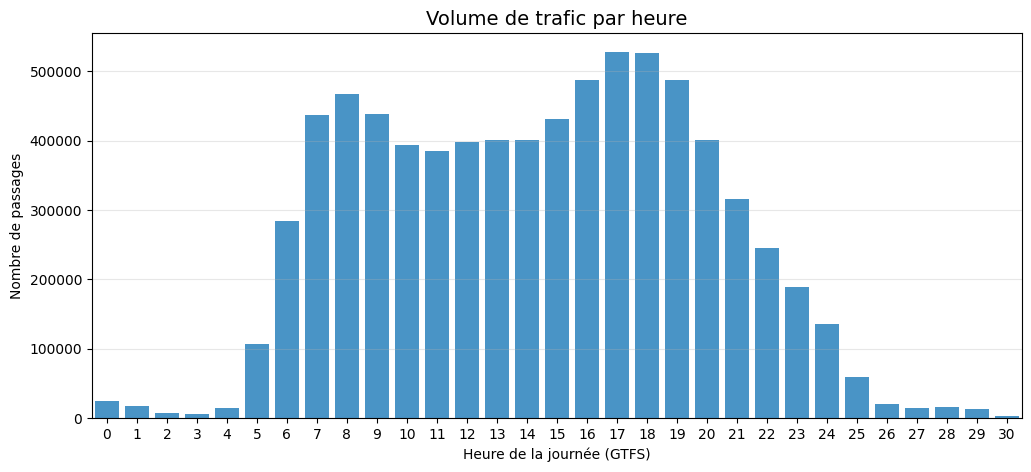

In [31]:
print("--- [1/8] Analyse Temporelle : Pics de fréquentation ---")

# on extrait l'heure et on filtre ce qui dépasse 29h pour la lisibilité
df_horaires = df_stop_times.withColumn("heure", substring(col("arrival_time"), 1, 2).cast("int")) \
                           .filter(col("heure") <= 30)

# agrégation
df_freq = df_horaires.groupBy("heure").count().orderBy("heure")

# viz
pdf_freq = df_freq.toPandas()
plt.figure(figsize=(12, 5))
sns.barplot(data=pdf_freq, x='heure', y='count', color='#3498db')
plt.title('Volume de trafic par heure', fontsize=14)
plt.xlabel('Heure de la journée (GTFS)'); plt.ylabel('Nombre de passages')
plt.grid(axis='y', alpha=0.3); plt.show()

#### **Interprétation de l'analyse temporelle**
Sur les axes du graphiques, on remarque d'abord que les heures de la journée **s'étendent jusqu'à 30h**.

Selon la norme GTFS, une journée de service ne s'arrête pas à minuit (24H), donc si un bus de nuit commence son service le soir termine le lendemain matin à 4h, ses horaires seront notés comme 24h, 25h, etc de la journée du début de service.

C'est pour cette raison que nous avons laissé la possibilité d'avoir un affichage des données jusqu'à 30h, car c'est généralement la fin du service standard de nuit.

Concernant le profil du trafic, on observe deux pics très nets s'apparentant aux déplacements domicile-travail :
* Un **pic matinal à 8h**, correspondant à l'arrivée au travail ou à l'école.
* Un **pic de soirée à 17h-18h**, correspondant aux retours, et légèrement plus étalé dans le temps.
* Une baisse relative en journée (de 11h à 14h), bien que le trafic reste soutenu.
La chute est drastique après 21h, marquant la fin du service de la plupart des lignes.

### 2. Analyse spatiale : densité par zone

**Problématique :** Quelle est la couverture géographique du réseau en fonction des zones tarifaires ?

Nous comptons ici le nombre d'arrêts physiques (`stops`) situés dans chaque zone (1 à 5).

--- [2/8] Analyse Spatiale : Densité par Zone ---


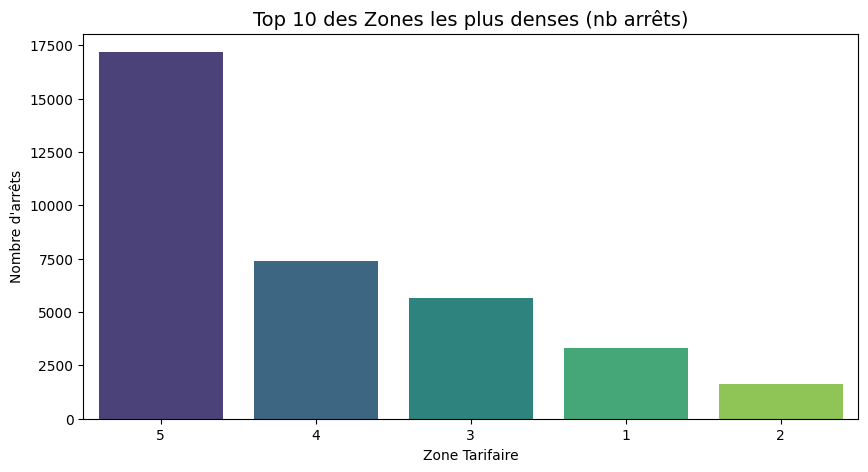

In [32]:
print("--- [2/8] Analyse Spatiale : Densité par Zone ---")

# Filtre : On garde les arrêts avec une zone_id
df_zones = df_stops.filter(col("zone_id").isNotNull()) \
                   .groupBy("zone_id").count() \
                   .orderBy(col("count").desc())

# Viz
pdf_zones = df_zones.limit(10).toPandas()
plt.figure(figsize=(10, 5))
sns.barplot(data=pdf_zones, x='zone_id', y='count', hue='zone_id', palette='viridis', order=pdf_zones['zone_id'])
plt.title('Top 10 des Zones les plus denses (nb arrêts)', fontsize=14)
plt.xlabel('Zone Tarifaire'); plt.ylabel('Nombre d\'arrêts')
plt.show()

#### **Interprétation de la répartition par zone**
Le graphique met en évidence une **domination massive de la zone 5** avec plus de 17 000 arrêts. Cela s'explique par la géographie car la zone 5 couvre une immense surface (la "Grande couronne" rurale et périurbaine), ce qui nécessite un grand nombre d'arrêts de bus pour desservir chaque commune.

À l'inverse, la **Zone 1 (Paris intra-muros)** et la Zone 2 semblent avoir moins d'arrêts. C'est une impression car ces zones sont plus petites mais extrêmement denses. Un seul arrêt de métro en Zone 1 voit passer beaucoup plus de monde qu'un arrêt de bus en Zone 5, mais ici on compte l'infrastructure par les voyageurs.

### 3. Analyse du réseau (les hubs)

**Problématique :** Quels sont les points de connexion les plus importants du réseau ?

Nous identifions les "Hubs" en comptant le nombre de lignes commerciales distinctes qui desservent chaque arrêt ou gare.

--- [3/8] Analyse Réseau : Les Hubs majeurs ---


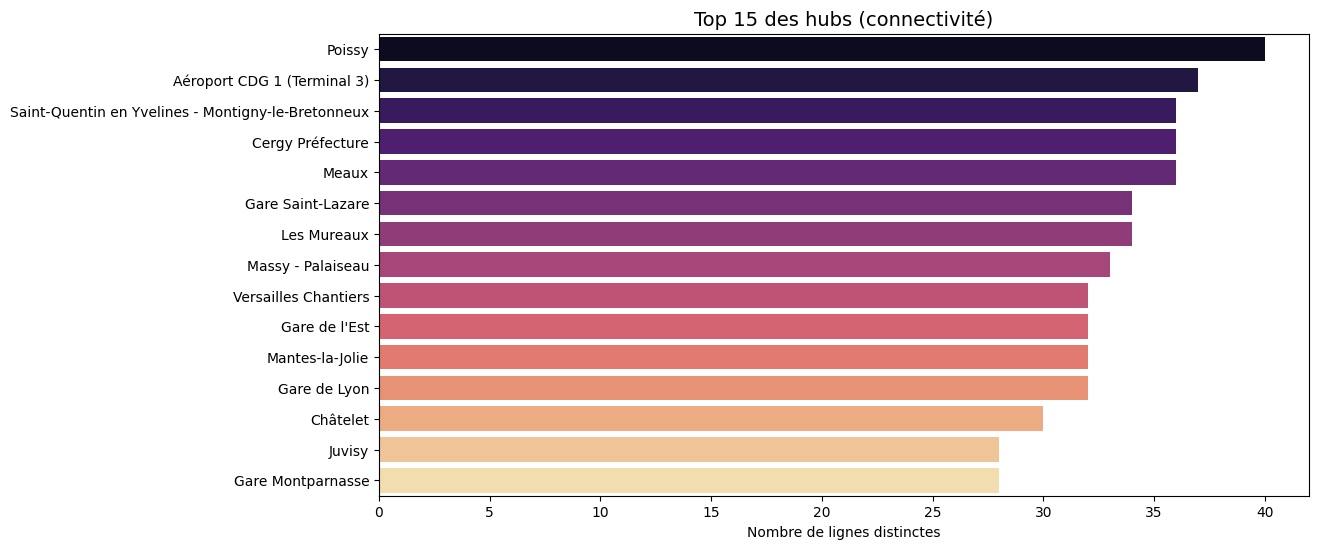

In [33]:
print("--- [3/8] Analyse Réseau : Les Hubs majeurs ---")

df_reseau = df_stop_times.join(df_trips, "trip_id").join(df_routes, "route_id")
df_reseau_full = df_reseau.join(df_stops, "stop_id")
df_hubs = df_reseau_full.withColumn("hub_id", coalesce(col("parent_station"), col("stop_id")))

df_classement = df_hubs.groupBy("hub_id") \
    .agg(countDistinct("route_short_name").alias("nb_lignes"))

df_top_hubs = df_classement.join(df_stops.alias("s"), col("hub_id") == col("s.stop_id")) \
    .select(col("s.stop_name").alias("Nom"), "nb_lignes") \
    .orderBy(col("nb_lignes").desc()) \
    .limit(15)

# Viz
pdf_hubs = df_top_hubs.toPandas()
plt.figure(figsize=(12, 6))
sns.barplot(
    data=pdf_hubs, 
    y='Nom', 
    x='nb_lignes', 
    hue='Nom',
    palette='magma',
    legend=False
)
plt.title('Top 15 des hubs (connectivité)', fontsize=14)
plt.xlabel('Nombre de lignes distinctes'); plt.ylabel('')
plt.show()

#### **Interprétation du top 15 des hubs**
Le classement révèle deux types de hubs :
* **Les Gares Routières de Grande Couronne** (Poissy, Meaux, Cergy, St-Quentin) : Elles arrivent en tête car elles concentrent des dizaines de lignes de bus locales qui circulent autour de la ville.
* **Les Grandes Gares Parisiennes** (St-Lazare, Gare de Lyon, Châtelet) : Elles ont moins de lignes en nombre absolu, mais ce sont des lignes à très haute capacité (RER, Métro, Train).

Ce graphique mesure donc la connectivité capilllaire (diversité des destinations bus) plutôt que le volume pur de passagers.

### 4. Analyse de la répartition modale

**Problématique :** Quelle est la composition du parc de lignes en Île-de-France ?

Le réseau est multimodal car il comprend des bus, métros, trams et RER. Nous analysons ici la proportion de lignes appartenant à chaque mode.

--- [4/8] Analyse Modale : Types de transport ---


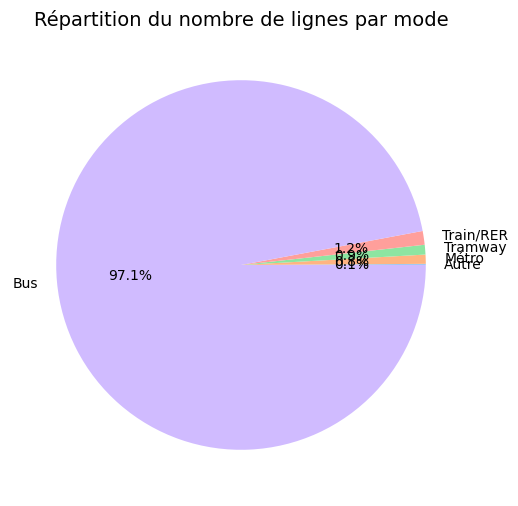

In [34]:
print("--- [4/8] Analyse Modale : Types de transport ---")

df_modes = df_routes.withColumn("mode", 
    when(col("route_type") == 3, "Bus")
    .when(col("route_type") == 1, "Métro")
    .when(col("route_type") == 0, "Tramway")
    .when(col("route_type") == 2, "Train/RER")
    .otherwise("Autre")
)
df_repart_modes = df_modes.groupBy("mode").count().orderBy("count")

# Viz (Camembert standard, pas de changement nécessaire)
pdf_modes = df_repart_modes.toPandas()
plt.figure(figsize=(6, 6))
plt.pie(pdf_modes['count'], labels=pdf_modes['mode'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Répartition du nombre de lignes par mode', fontsize=14)
plt.show()

#### **Interprétation de la répartition des modes de transport**
Cette analyse fait clairement sortir un point : **97.1% des lignes sont des lignes de Bus**.

Bien que le Métro et le RER (avec moins de 3% cumulés) transportent la majorité des voyageurs quotidiens, ils ne constituent pas la majorité dans cette analyse car on comptabilise ici le nombre de lignes du réseau. 

Le Bus assure une déserte répandue sur tout le territoire, expliquant pourquoi il y a des milliers de lignes de bus pour seulement 16 lignes de métro et 5 lignes de RER.

### 5. Analyse des opérateurs de transport

**Problématique :** Quels sont les acteurs qui gèrent le réseau de transport francilien ?

Depuis l'ouverture à la concurrence en grande couronne, de multiples opérateurs coexistent. Nous cherchons à déterminer qui gère le plus grand nombre de lignes.

--- [5/8] Analyse Opérateurs : Qui gère le réseau ? ---


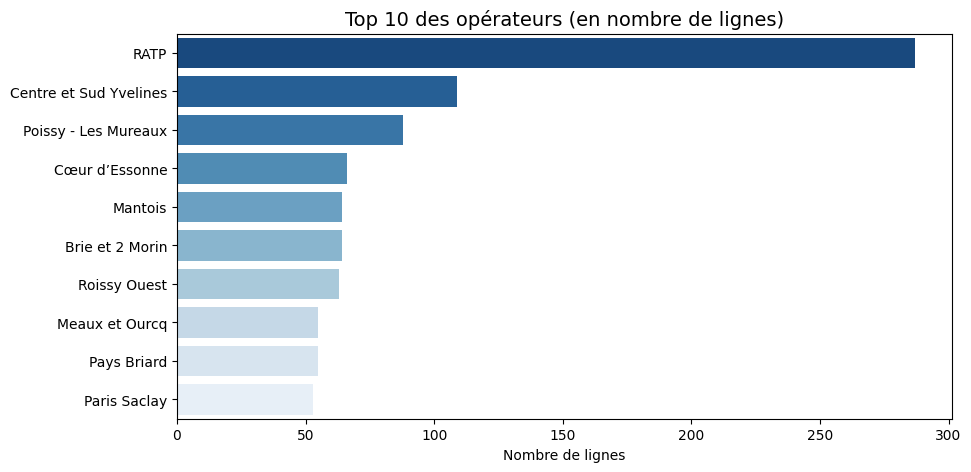

In [35]:
print("--- [5/8] Analyse Opérateurs : Qui gère le réseau ? ---")

df_ops = df_routes.join(df_agency, "agency_id") \
    .groupBy("agency_name").count() \
    .orderBy(col("count").desc()) \
    .limit(10)

# Viz CORRIGÉE
pdf_ops = df_ops.toPandas()
plt.figure(figsize=(10, 5))
sns.barplot(
    data=pdf_ops, 
    y='agency_name', 
    x='count', 
    hue='agency_name',
    palette='Blues_r',
    legend=False
)
plt.title('Top 10 des opérateurs (en nombre de lignes)', fontsize=14)
plt.xlabel('Nombre de lignes'); plt.ylabel('')
plt.show()

#### **Interprétation de la répartiton des opérateurs**
On constate que la **RATP** domine largement le classement, gérant le cœur historique du réseau (Paris et Petite Couronne).

Cependant, on voit apparaître de nombreux autres noms (Centre et Sud Yvelines, Cœur d'Essonne, etc.). Ce sont des opérateurs, souvent des filiales de Keolis ou Transdev, qui gèrent les réseaux de bus locaux en Grande Couronne. 

Cela illustre la fragmentation administrative du réseau en dehors de Paris.

### 6. Analyse de la complexité (les lignes les plus longues)

**Problématique :** Quelles sont les lignes les plus "longues" et les plus complexes en termes de desserte ?

Nous identifions ici les lignes "Omnibus" qui desservent le plus grand nombre d'arrêts uniques sur un seul trajet.

--- [6/8] Lignes les plus longues (Noms nettoyés) ---


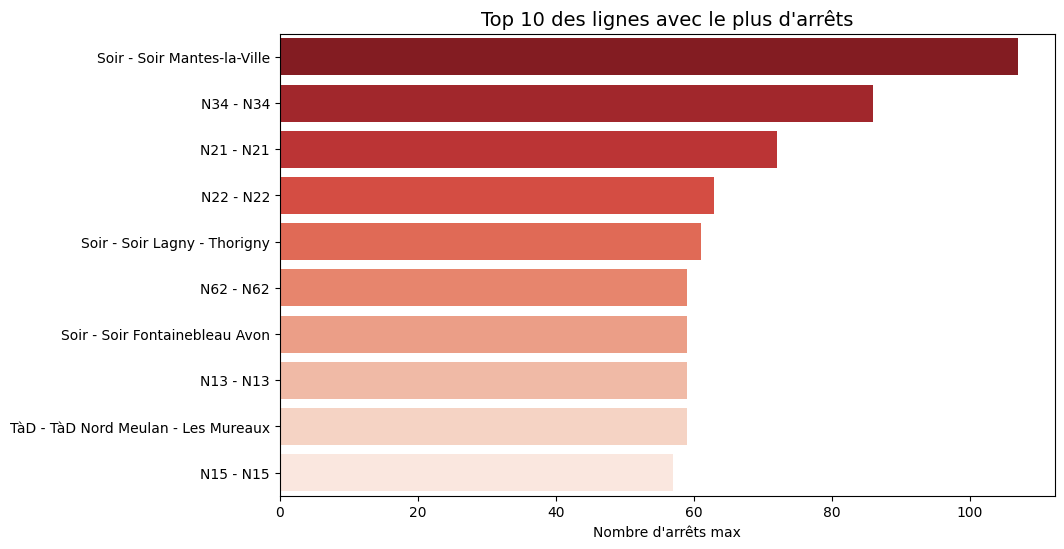

In [36]:
from pyspark.sql.functions import col, count, max as spark_max, concat, lit, coalesce, when, substring

print("--- [6/8] Lignes les plus longues (Noms nettoyés) ---")

stops_per_trip = df_stop_times.groupBy("trip_id").count()

# On crée une colonne "Nom_Complet" : "Short - Long"
df_routes_clean = df_routes.withColumn(
    "nom_complet", 
    concat(col("route_short_name"), lit(" - "), coalesce(col("route_long_name"), lit("")))
)

df_complex = stops_per_trip.join(df_trips, "trip_id") \
    .join(df_routes_clean, "route_id") \
    .groupBy("nom_complet") \
    .agg(spark_max("count").alias("max_arrets")) \
    .orderBy(col("max_arrets").desc()) \
    .limit(10)

pdf_complex = df_complex.toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=pdf_complex, y='nom_complet', x='max_arrets', hue='nom_complet', palette='Reds_r', legend=False)
plt.title('Top 10 des lignes avec le plus d\'arrêts', fontsize=14)
plt.xlabel("Nombre d'arrêts max"); plt.ylabel("")
plt.show()

#### **Interprétation du top 10 des lignes les plus complexes**
Les lignes apparaissant dans ce top 10 (dépassant souvent les 60 arrêts) sont typiquement :
* Des lignes **Noctilien** (ex: N34, N21) : Ces bus de nuit traversent toute la région pour remplacer les RER, s'arrêtant partout.
* Des lignes de **bus interurbains** en zone rurale (ex: Mantes-la-Ville, Fontainebleau) qui jouent un rôle de cabotage en desservant de nombreux villages successifs.

### 7. Analyse de l'offre en semaine et en week-end

**Problématique :** L'offre de transport diffère-t-elle entre la semaine de travail et le week-end ?

Nous croisons les données horaires avec le calendrier de service pour comparer les courbes de trafic.

--- [7/8] Analyse Avancée : Profil Horaire Semaine vs WE ---


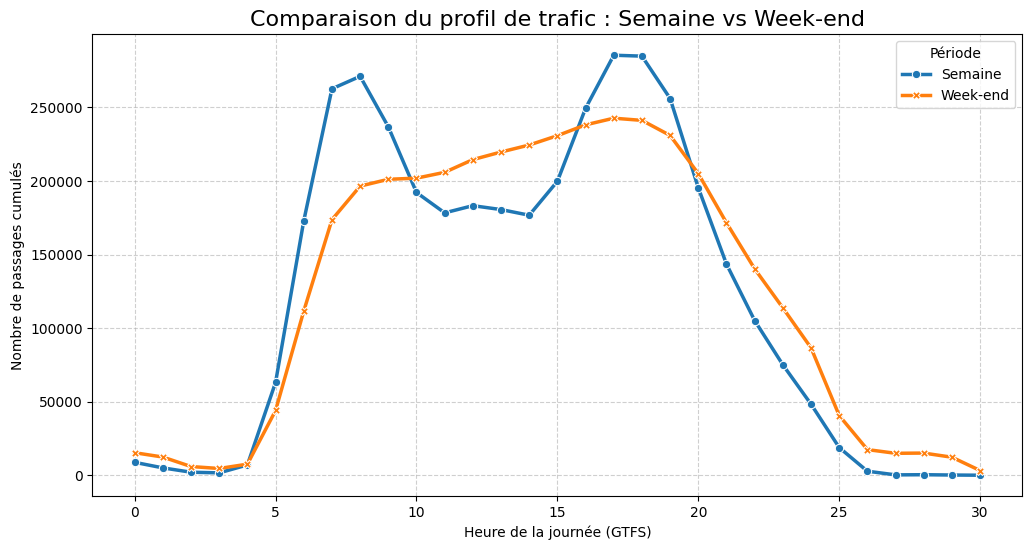

In [37]:
print("--- [7/8] Analyse Avancée : Profil Horaire Semaine vs WE ---")

# 1. Classification des Service_ID (Semaine ou Week-end ?)
schema_cal = StructType([
    StructField("service_id", StringType(), True),
    StructField("monday", IntegerType(), True),
    StructField("tuesday", IntegerType(), True),
    StructField("wednesday", IntegerType(), True),
    StructField("thursday", IntegerType(), True),
    StructField("friday", IntegerType(), True),
    StructField("saturday", IntegerType(), True),
    StructField("sunday", IntegerType(), True),
    StructField("start_date", StringType(), True),
    StructField("end_date", StringType(), True)
])
# On utilise les options CSV définies plus haut (csv_opts)
df_calendar = spark.read.schema(schema_cal).options(**csv_opts).csv(base_path + "calendar.txt")

# On étiquette : Si Samedi=1 OU Dimanche=1 alors "Week-end", sinon "Semaine"
df_cal_type = df_calendar.withColumn("type_jour", 
    when((col("saturday") == 1) | (col("sunday") == 1), "Week-end")
    .otherwise("Semaine")
).select("service_id", "type_jour")

# 2. Jointure optimisée : stop_times -> trips -> calendar(type)
# On ne garde que les colonnes utiles pour accélérer
df_horaire_type = df_stop_times.select("trip_id", "arrival_time") \
    .join(df_trips.select("trip_id", "service_id"), "trip_id") \
    .join(df_cal_type, "service_id")

# 3. Extraction Heure et Agrégation (Bornée à 29h pour la lisibilité)
df_comparatif = df_horaire_type.withColumn("heure", substring(col("arrival_time"), 1, 2).cast("int")) \
    .filter(col("heure") <= 30) \
    .groupBy("heure", "type_jour") \
    .count() \
    .orderBy("heure")

# 4. Visualisation (Courbes)
pdf_comparatif = df_comparatif.toPandas()

plt.figure(figsize=(12, 6))
# Lineplot permet de tracer des courbes facilement avec seaborn
sns.lineplot(
    data=pdf_comparatif, 
    x='heure', 
    y='count', 
    hue='type_jour', 
    style='type_jour', 
    markers=True, 
    dashes=False, 
    linewidth=2.5
)

plt.title('Comparaison du profil de trafic : Semaine vs Week-end', fontsize=16)
plt.xlabel('Heure de la journée (GTFS)')
plt.ylabel('Nombre de passages cumulés')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Période')
plt.show()

#### **Interprétation de la différence de service entre semaine et week-end**
La comparaison des courbes permet de constater que :
* **En Semaine (courbe bleue) :** On remarque une forme en "M" avec deux pics de pointe (à 8h et 17h) liés aux horaires de bureau et scolaires.
* **Le Week-end (courbe orange) :** La courbe est beaucoup plus lisse, un peu en forme de cloche. Il n'y a pas de pic le matin, car les gens se lèvent plus tard, et le trafic monte progressivement en journée pour atteindre son maximum en milieu d'après-midi, certainement pour les loisirs et les courses, avant de redescendre doucement le soir.

### 8. Analyse de la cartographie des arrêts

**Problématique :** A quoi ressemble géographiquement le réseau sur le territoire francilien ?

Nous utilisons les coordonnées GPS des 54 000 arrêts pour dessiner la carte de l'Île-de-France, colorée par zone tarifaire.

--- [8/8] Analyse Géographique : La carte des arrêts ---


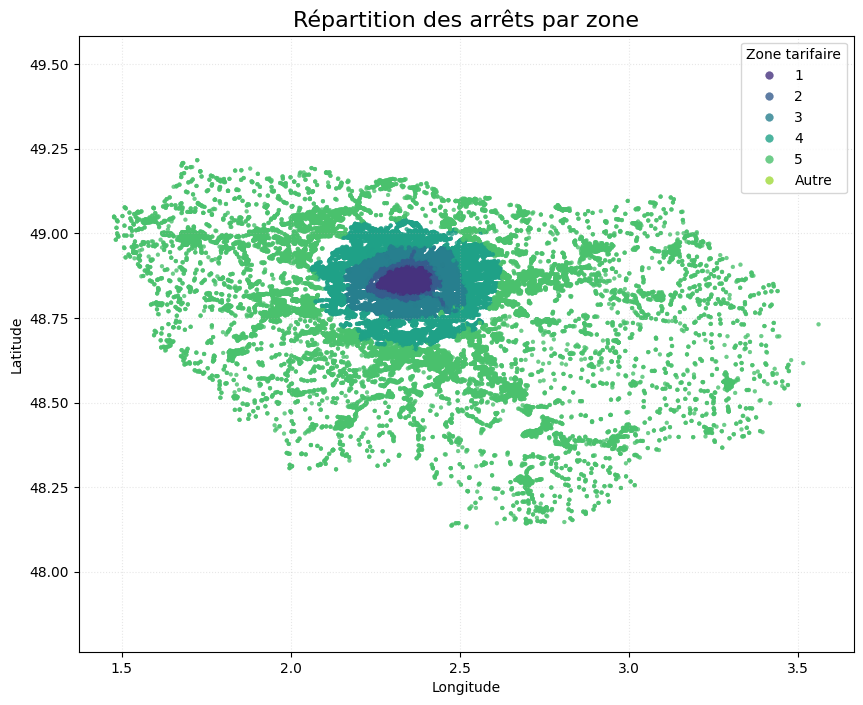

In [39]:
print("--- [8/8] Analyse Géographique : La carte des arrêts ---")

# préparation dans Spark
# on filtre les lat/lon invalides et les zones nulles dès le début.
df_geo = df_stops.select("stop_lon", "stop_lat", "zone_id") \
    .filter(
        (col("stop_lat").isNotNull()) & 
        (col("stop_lat") != 0) & 
        (col("stop_lon") != 0) &
        (col("zone_id").isNotNull())
    )

# conversion en pandas
pdf_geo = df_geo.toPandas()

# DIAGNOSTIC RAPIDE (Pour comprendre pourquoi c'était vert)
# print("Valeurs brutes trouvées dans zone_id (Top 10) :")
# print(pdf_geo['zone_id'].unique()[:10])

# nettoyage
# conversion en string + découpage des décimales éventuelles et des espaces
def clean_zone_final(z):
    z = str(z).strip()
    if z.endswith('.0'): 
        z = z[:-2]
    
    # si c'est bien 1, 2, 3, 4 ou 5, on garde
    if z in ['1', '2', '3', '4', '5']:
        return z
    return 'Autre'

pdf_geo['zone_visu'] = pdf_geo['zone_id'].apply(clean_zone_final)

# Vérification finale de la répartition
# print("\nRépartition des couleurs pour la carte :")
# print(pdf_geo['zone_visu'].value_counts())

# visualisation
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=pdf_geo,
    # la latitude et la longitude sont inversés donc j'ai attribué l'inverse à x et à y
    x='stop_lat',
    y='stop_lon',
    hue='zone_visu',
    hue_order=['1', '2', '3', '4', '5', 'Autre'],
    palette='viridis', 
    s=8,
    alpha=0.8,
    edgecolor=None
)

plt.title('Répartition des arrêts par zone', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('equal') 
plt.legend(title='Zone tarifaire', markerscale=2, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)
plt.show()

#### **Interprétation de la carte du réseau francilien**
Cette visualisation permet de reconstruire la géographie de l'Île-de-France uniquement à partir des données :
* Le milieu bleu foncé correspond à **Paris (Zone 1)** et sa très forte densité.
* On observe ensuite une structure en **cercles** (Zone 2, 3, 4) qui s'élargissent.
* La **Zone 5 (vert clair)** couvre l'immense périphérie.
* Les "bras" ou les lignes d'arrêts qui s'étirent vers l'extérieur suivent généralement les axes des voies ferrées (RER) ou les grandes nationales, le long desquels l'urbanisation s'est développée.